## Building a GPT

Companion notebook to the [Zero To Hero](https://karpathy.ai/zero-to-hero.html) video on GPT.

In [1]:
from nltk.tokenize.toktok import ToktokTokenizer
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [2]:
# We always start with a dataset to train on. Let's download the tiny shakespeare dataset
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2023-05-22 20:36:46--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.05s   

2023-05-22 20:36:46 (19.6 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [3]:
# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [4]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115394


In [5]:
# let's look at the first 1000 characters
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [6]:
tokenizer1=ToktokTokenizer() #to tokenize our sequence into tokens
stopword_list=nltk.corpus.stopwords.words('english') #because we have english reviews 
exclude= string.punctuation #return string with removed punctiation 

In [7]:
def lowercase(text):
    """
    helper function which lowercases a single document 
    
    Arguments:
    text -- takes one text review at a time
    
    Returns:
    text.lower -- python string of document with lowercase text
    """
    return text.lower()

In [8]:
def rem_punctn(text):
    """
    helper function to remove Punctuations from  a document
    
    Arguments:
    text -- takes one text review at a time
    
    Returns:
    String -- python string with removed Punctuations
    """
    return text.translate(str.maketrans('','', exclude))

In [9]:
def remove_stopwords(text):
    """
    helper function to stop words from a document
    
    Arguments:
    text -- takes one text review at a time
    
    Returns:
    string -- python string with removed stopwords
    """
    tokens = tokenizer1.tokenize(text)
    tokens = [token.strip() for token in tokens]
    filtered_tokens = [token for token in tokens if token not in stopword_list]

    filtered_text = ' '.join(filtered_tokens)    
    return filtered_text

In [10]:
def lemma_traincorpus(text):
    lemmatizer=WordNetLemmatizer()
    out_data=""
    for words in text:
        out_data+= lemmatizer.lemmatize(words)
    return out_data

In [11]:
text = lowercase(text)
text = rem_punctn(text)
text = remove_stopwords(text)
text = lemma_traincorpus(text)
print(text[:1000])

first citizen proceed hear speak speak speak first citizen resolved rather die famish resolved resolved first citizen first know caius marcius chief enemy people knowt knowt first citizen let us kill well corn price ist verdict talking ont let done away away second citizen one word good citizens first citizen accounted poor citizens patricians good authority surfeits would relieve us would yield us superfluity wholesome might guess relieved us humanely think dear leanness afflicts us object misery inventory particularise abundance sufferance gain let us revenge pikes ere become rakes gods know speak hunger bread thirst revenge second citizen would proceed especially caius marcius first hes dog commonalty second citizen consider services done country first citizen well could content give good report fort pays proud second citizen nay speak maliciously first citizen say unto hath done famously end though softconscienced men content say country please mother partly proud even till altitud

In [12]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 3abcdefghijklmnopqrstuvwxyz
28


###Unique Characters where 65 it contained all the alphabet as capital and small letters also contained many punctuations like #?!."

In [13]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("hii there"))
print(decode(encode("hii there")))

[9, 10, 10, 0, 21, 9, 6, 19, 6]
hii there


In [14]:
# let's now encode the entire text dataset and store it into a torch.Tensor
import torch # we use PyTorch: https://pytorch.org
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # the 1000 characters we looked at earier will to the GPT look like this

torch.Size([692445]) torch.int64
tensor([ 7, 10, 19, 20, 21,  0,  4, 10, 21, 10, 27,  6, 15,  0, 17, 19, 16,  4,
         6,  6,  5,  0,  9,  6,  2, 19,  0, 20, 17,  6,  2, 12,  0, 20, 17,  6,
         2, 12,  0, 20, 17,  6,  2, 12,  0,  7, 10, 19, 20, 21,  0,  4, 10, 21,
        10, 27,  6, 15,  0, 19,  6, 20, 16, 13, 23,  6,  5,  0, 19,  2, 21,  9,
         6, 19,  0,  5, 10,  6,  0,  7,  2, 14, 10, 20,  9,  0, 19,  6, 20, 16,
        13, 23,  6,  5,  0, 19,  6, 20, 16, 13, 23,  6,  5,  0,  7, 10, 19, 20,
        21,  0,  4, 10, 21, 10, 27,  6, 15,  0,  7, 10, 19, 20, 21,  0, 12, 15,
        16, 24,  0,  4,  2, 10, 22, 20,  0, 14,  2, 19,  4, 10, 22, 20,  0,  4,
         9, 10,  6,  7,  0,  6, 15,  6, 14, 26,  0, 17,  6, 16, 17, 13,  6,  0,
        12, 15, 16, 24, 21,  0, 12, 15, 16, 24, 21,  0,  7, 10, 19, 20, 21,  0,
         4, 10, 21, 10, 27,  6, 15,  0, 13,  6, 21,  0, 22, 20,  0, 12, 10, 13,
        13,  0, 24,  6, 13, 13,  0,  4, 16, 19, 15,  0, 17, 19, 10,  4,  6,  0,
       

In [15]:
# Let's now split up the data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [16]:
block_size = 8
train_data[:block_size+1]

tensor([ 7, 10, 19, 20, 21,  0,  4, 10, 21])

In [17]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([7]) the target: 10
when input is tensor([ 7, 10]) the target: 19
when input is tensor([ 7, 10, 19]) the target: 20
when input is tensor([ 7, 10, 19, 20]) the target: 21
when input is tensor([ 7, 10, 19, 20, 21]) the target: 0
when input is tensor([ 7, 10, 19, 20, 21,  0]) the target: 4
when input is tensor([ 7, 10, 19, 20, 21,  0,  4]) the target: 10
when input is tensor([ 7, 10, 19, 20, 21,  0,  4, 10]) the target: 21


In [18]:
print(text[:100])

first citizen proceed hear speak speak speak first citizen resolved rather die famish resolved resol


In [19]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[13, 26,  0, 17,  2, 10, 15, 21],
        [22, 19,  0, 12, 15, 16, 24,  0],
        [ 6,  0,  3,  6, 19,  6,  2, 23],
        [16, 21,  9,  6, 19,  0, 13,  6]])
targets:
torch.Size([4, 8])
tensor([[26,  0, 17,  2, 10, 15, 21, 10],
        [19,  0, 12, 15, 16, 24,  0, 21],
        [ 0,  3,  6, 19,  6,  2, 23,  6],
        [21,  9,  6, 19,  0, 13,  6, 21]])
----
when input is [13] the target: 26
when input is [13, 26] the target: 0
when input is [13, 26, 0] the target: 17
when input is [13, 26, 0, 17] the target: 2
when input is [13, 26, 0, 17, 2] the target: 10
when input is [13, 26, 0, 17, 2, 10] the target: 15
when input is [13, 26, 0, 17, 2, 10, 15] the target: 21
when input is [13, 26, 0, 17, 2, 10, 15, 21] the target: 10
when input is [22] the target: 19
when input is [22, 19] the target: 0
when input is [22, 19, 0] the target: 12
when input is [22, 19, 0, 12] the target: 15
when input is [22, 19, 0, 12, 15] the target: 16
when input is [22, 19, 0

In [20]:
print(xb) # our input to the transformer

tensor([[13, 26,  0, 17,  2, 10, 15, 21],
        [22, 19,  0, 12, 15, 16, 24,  0],
        [ 6,  0,  3,  6, 19,  6,  2, 23],
        [16, 21,  9,  6, 19,  0, 13,  6]])


In [21]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)
        
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


torch.Size([32, 28])
tensor(3.8526, grad_fn=<NllLossBackward0>)
 en3u nqkpiqhvtybnsvnfkomoty ourqytygmv3jkqowbwpbxdzhuleomhtq3wiu 3bcpkqhae3ycpwahy haqcscjnsguxjfrqy


In [22]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

In [23]:
batch_size = 32
for steps in range(100): # increase number of steps for good results... 
    
    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())


3.887228488922119


In [24]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=500)[0].tolist()))

 cidftfzs fbaomctpazzzsrkvtyffteohh tydvn xkty lbxyvtkbypulbol3yoybxhvbpouvvtypawscuzbe3xhbxdqhbcxkvmxio3bgvtu dcydcpwey udvtmxbcawikojkcqncty hapudvt3ynsru wzokoifyhcgpkwkpwoutzulxdatsodvt l3bxetf eqhfxetwpa dc3xjbhf rolbxjftpbgxijaelu qnwwaodbgoahoawl3xmbhwsvtawevtrul3bezlq3u olaihfsvtqyprin ohwiu n3bxvhbnfu nqchulomvfievzjn3y eitycciwof umbxvbwvjkaoivn3xjn3me3xvtprhis djacfscglfflrdcg3bgipfbawvtwzkaetuzae3xdvtfbxixdvdavnwiugcgoaoxkiprctoaots kbzjkvkqpsu rcqcsmvtlxpguqcszu nfyjkvpgu3bpohfcyty r


## The mathematical trick in self-attention

In [25]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [26]:
# consider the following toy example:

torch.manual_seed(1337)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [27]:
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow[b,t] = torch.mean(xprev, 0)


In [28]:
# version 2: using matrix multiply for a weighted aggregation
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C)
torch.allclose(xbow, xbow2)

True

In [29]:
# version 3: use Softmax
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x
torch.allclose(xbow, xbow3)


True

In [30]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
#out = wei @ x

out.shape

torch.Size([4, 8, 16])

In [31]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

Notes:
- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.
- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.
- Each example across batch dimension is of course processed completely independently and never "talk" to each other
- In an "encoder" attention block just delete the single line that does masking with `tril`, allowing all tokens to communicate. This block here is called a "decoder" attention block because it has triangular masking, and is usually used in autoregressive settings, like language modeling.
- "self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, external source (e.g. an encoder module)
- "Scaled" attention additional divides `wei` by 1/sqrt(head_size). This makes it so when input Q,K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much. Illustration below

In [32]:
k = torch.randn(B,T,head_size)
q = torch.randn(B,T,head_size)
wei = q @ k.transpose(-2, -1) * head_size**-0.5

In [33]:
k.var()

tensor(1.0449)

In [34]:
q.var()

tensor(1.0700)

In [35]:
wei.var()

tensor(1.0918)

In [36]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5]), dim=-1)

tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])

In [37]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])*8, dim=-1) # gets too peaky, converges to one-hot

tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])

In [38]:
class LayerNorm1d: # (used to be BatchNorm1d)
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    xmean = x.mean(1, keepdim=True) # batch mean
    xvar = x.var(1, keepdim=True) # batch variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

torch.manual_seed(1337)
module = LayerNorm1d(100)
x = torch.randn(32, 100) # batch size 32 of 100-dimensional vectors
x = module(x)
x.shape

torch.Size([32, 100])

In [39]:
x[:,0].mean(), x[:,0].std() # mean,std of one feature across all batch inputs

(tensor(0.1469), tensor(0.8803))

In [40]:
x[0,:].mean(), x[0,:].std() # mean,std of a single input from the batch, of its features

(tensor(-9.5367e-09), tensor(1.0000))

In [41]:
# French to English translation example:

# <--------- ENCODE ------------------><--------------- DECODE ----------------->
# les réseaux de neurones sont géniaux! <START> neural networks are awesome!<END>



In [42]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

### Full finished code, for reference

You may want to refer directly to the git repo instead though.

first citizen proceed hear speak speak speak first citizen resolved rather die famish resolved resolved first citizen first know caius marcius chief enemy people knowt knowt first citizen let us kill well corn price ist verdict talking ont let done away away second citizen one word good citizens first citizen accounted poor citizens patricians good authority surfeits would relieve us would yield us superfluity wholesome might guess relieved us humanely think dear leanness afflicts us object misery inventory particularise abundance sufferance gain let us revenge pikes ere become rakes gods know speak hunger bread thirst revenge second citizen would proceed especially caius marcius first hes dog commonalty second citizen consider services done country first citizen well could content give good report fort pays proud second citizen nay speak maliciously first citizen say unto hath done famously end though softconscienced men content say country please mother partly proud even till altitud

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


step 0: train loss 3.5376, val loss 3.5484
Accuracy: 0.0332
Precision: 0.0701
Recall: 0.0332
F1 Score: 0.0315


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


step 100: train loss 2.4706, val loss 2.4883
Accuracy: 0.2242
Precision: 0.1775
Recall: 0.2242
F1 Score: 0.1753


...

step 9800: train loss 1.4897, val loss 1.6879
Accuracy: 0.4675
Precision: 0.5037
Recall: 0.4675
F1 Score: 0.4608


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


step 9900: train loss 1.4896, val loss 1.7154
Accuracy: 0.4648
Precision: 0.4943
Recall: 0.4648
F1 Score: 0.4533


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


step 9999: train loss 1.4837, val loss 1.6888
Accuracy: 0.4708
Precision: 0.5008
Recall: 0.4708
F1 Score: 0.4601
Perplexity at iteration 9999: 2.7784


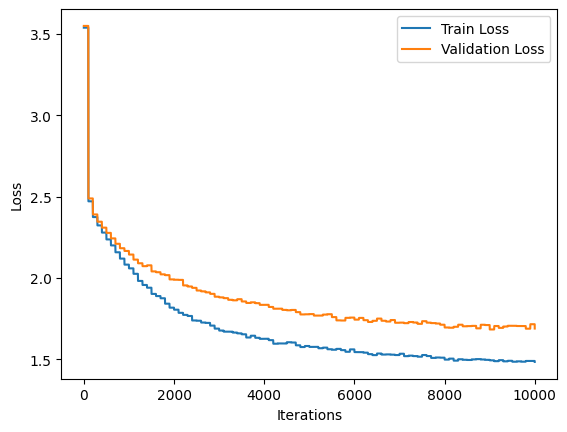

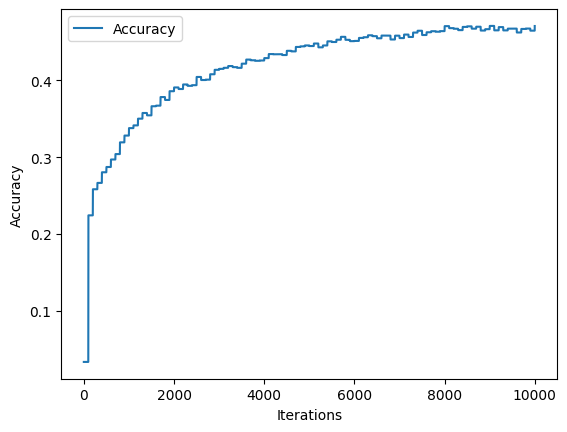

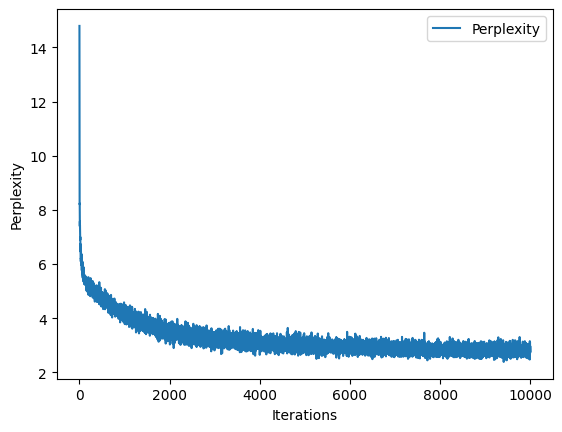

 doors shall guilty thyself leaves vose elbody ha romeo take honest added followed words lives sea duke ismiliam onother pilibert last coblequious delike hourse waid then sir asspect love reprome left isaintd offender fool thy nowned hearing take think mhan brought meven ill foon go mone dam whily mortake york shall reob bavast lady polible findeed thou worthinkst abushy last air patied jest ensilies god strike give bittess broke peace sledellizes stiterance brought roman good whoefe awhoris moure mad spressent say lince recontry thou haman blouinishing devileve depolixerione heart chows death would thou lip sap testime thy twonder haurt propes sudden warret romeo tongue hoold foe boy barrow kill shall maday lics boys state doathful clownd earthly death ever hold brutus lap though clarents rots whose banishily reconce kingsnowly vusto sweet god beg wall amend corizal man valiana rebs jourious victors heard duchess fith thy ithough riches master part mother god mets bohoy buttle madessi

In [44]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 10000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
# ------------

torch.manual_seed(1337)

# wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
    text = lowercase(text)
    text = rem_punctn(text)
    text = remove_stopwords(text)
    text = lemma_traincorpus(text)
    print(text[:1000])

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y



def calculate_metrics(y_true, y_pred):
    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Calculate precision, recall, and F1 score
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, cm
    

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        y_true = []
        y_pred = []
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()

            # Generate predictions
            preds = logits.argmax(dim=-1)
            y_true.extend(Y.flatten().tolist())
            y_pred.extend(preds.flatten().tolist())

        accuracy, precision, recall, f1, cm = calculate_metrics(y_true, y_pred)
        out[split] = {
            'loss': losses.mean(),
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': cm
        }
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx
    


model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []
accuracies = []
perplexities = []

for iter in range(max_iters):
     # calculate perplexity
    perplexity = 2 ** loss.item()
    perplexities.append(perplexity)

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']['loss']:.4f}, val loss {losses['val']['loss']:.4f}")
        print(f"Accuracy: {losses['val']['accuracy']:.4f}")
        print(f"Precision: {losses['val']['precision']:.4f}")
        print(f"Recall: {losses['val']['recall']:.4f}")
        print(f"F1 Score: {losses['val']['f1']:.4f}")
        

    
    # sample a batch of data
    xb, yb = get_batch('train')
    train_losses.append(losses['train']['loss'].item())
    val_losses.append(losses['val']['loss'].item())
    accuracies.append(losses['val']['accuracy'])

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    
print(f"Perplexity at iteration {iter}: {perplexity:.4f}")
# Plot losses
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot accuracy
plt.plot(accuracies, label='Accuracy')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot perplexity
plt.plot(perplexities, label='Perplexity')
plt.xlabel('Iterations')
plt.ylabel('Perplexity')
plt.legend()
plt.show()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
# after training the model

# save the model state dictionary
torch.save(model.state_dict(), '/content/drive/My Drive/Models/model.pth')

In [47]:
# before using the model

# create a new instance of the model
model = BigramLanguageModel()

# load the saved state dictionary into the model
model.load_state_dict(torch.load('/content/drive/My Drive/Models/model.pth'))

# move the model to the desired device
model.to(device)

BigramLanguageModel(
  (token_embedding_table): Embedding(28, 64)
  (position_embedding_table): Embedding(32, 64)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=64, out_features=16, bias=False)
            (query): Linear(in_features=64, out_features=16, bias=False)
            (value): Linear(in_features=64, out_features=16, bias=False)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (proj): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffwd): FeedFoward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=64, bias=True)
          (3): Dropout(p=0.0, inplace=False)
        )
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    